In [210]:
# importing librariess

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import math

# Uncoordinated Human Responses During Epidemic Outbreaks

### Quantities:
- S = fraction of pop. susceptible
- I = fraction of pop. infect
- R = fraction of pop. removed
- M = Infect perceived by the population
- x = fraction of pop. which adopt normal behavior

### Parameters:
- $\beta$ = transmission rate
- 1/$\gamma$ = avg duration of infectivity
- q = reduction of the risk of infection (due to altered behavior)
- v = weight of the decay of the perceived prevalence
- $\rho$ = speed of the imitation process with respect to pathogen transmission dynamics
- m = risk threshold for determining which behavior would represent the most convenient choice



### Model



---

In [211]:
# model definition:
def dSdt(beta, I, S, q, x):
    return -beta * I * S * (x + q*(1-x))
def dIdt(beta, I, S, q, x, gamma):
    return beta * I * S * (x + q*(1-x)) - gamma * I
def dRdt(I, gamma):
    return gamma * I
def dMdt(beta, I, S, q, x, v, M):
    return beta * I * S * (x + q*(1-x)) - v * M
def dxdt(beta, I, S, q, x, m, M, rho):
    dx = x*(1-x)*(q*beta*I - beta*I) + rho*x*(1-x)*(1-m*M)*S
    return max(-x, min(dx, 1 - x))


# simulation
def compute_model(initial_cond, beta, gamma, q, v, rho, m, t_span, t_eval):
    
    def Model(t, y):
        S, I, R, M, x = y
        dS = dSdt(beta, I, S, q, x)
        dI = dIdt(beta, I, S, q, x, gamma)
        dR = dRdt(I, gamma)
        dM = dMdt(beta, I, S, q, x, v, M)
        dx = dxdt(beta, I, S, q, x, m, M, rho)

        return [dS, dI, dR, dM, dx]
    
    # Risoluzione del sistema di equazioni differenziali
    sol = solve_ivp(Model, t_span, initial_cond, t_eval=t_eval)

    S_vec = sol.y[0]
    I_vec = sol.y[1]
    R_vec = sol.y[2]
    M_vec = sol.y[3]
    x_vec = sol.y[4]

    return sol.t, S_vec, I_vec, R_vec, M_vec, x_vec


# Calculating the Reproduction number over time
def compute_R0(x_vec, q, beta, gamma):
    R0_base = beta/gamma
    return R0_base * (x_vec + q * (1 - x_vec))

## Simulations

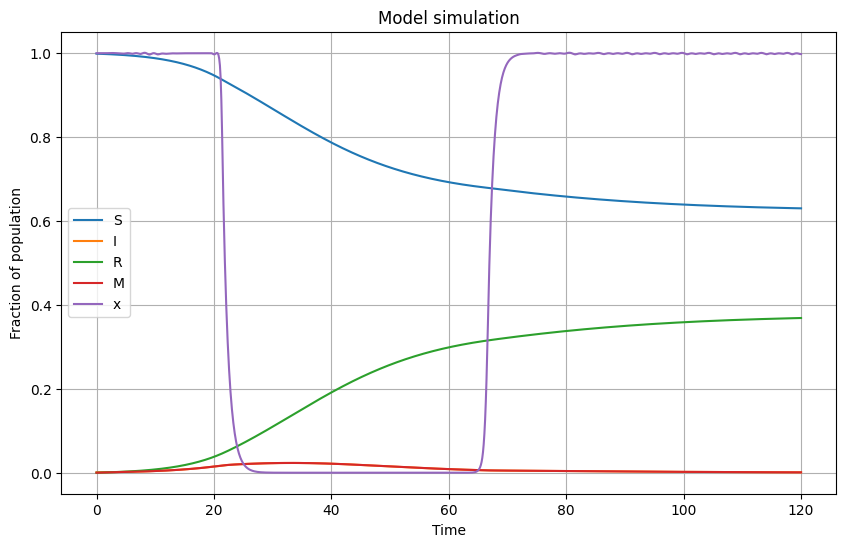

In [ ]:
## defining parameters for the first simulation
t_span = (0, 120)
t_eval = np.linspace(*t_span, 1000)

initial_cond = [1-10**(-3), 10**(-3), 0, 0, 1-(10**(-6))]

beta = 0.5
q = 0.85
gamma = 1/2.8
v = gamma
rho = 10
m = 100

# compute the model
t, S_vec, I_vec, R_vec, M_vec, x_vec = compute_model(initial_cond, beta, gamma, q, v, rho, m, t_span, t_eval)

# compute the model with no responsiveness so q = 1
_, _, I_no_res, _, _, _ = compute_model(initial_cond, beta, gamma, 1, v, rho, m, t_span, t_eval)

plot = plt.figure(figsize=(10, 6))
plt.plot(t, S_vec, label='S')
plt.plot(t, I_vec, label='I')
plt.plot(t, R_vec, label='R')
plt.plot(t, M_vec, label='M')
plt.plot(t, x_vec, label='x')
plt.legend()
plt.grid()
plt.xlabel('Time')
plt.ylabel('Fraction of population')
plt.title('Model simulation')
plt.show()


Text(0.5, 1.0, 'Infected population')

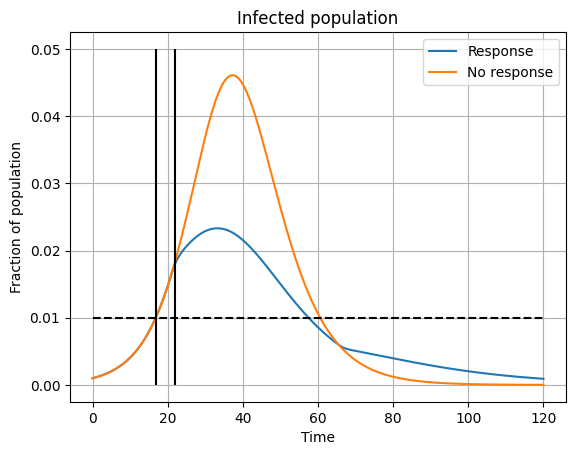

In [213]:
plt.plot(t, I_vec, label='Response')
plt.plot(t, I_no_res, label = 'No response')

threshold = 1/m
plt.plot(t, np.ones(len(t))*threshold, c= 'black', linestyle = '--')

plt.vlines(22, 0, 0.05, colors = 'black')
plt.vlines(17, 0, 0.05, colors = 'black')
plt.legend()
plt.grid('true')
plt.xlabel('Time')
plt.ylabel('Fraction of population')
plt.title('Infected population')

Text(0.5, 1.0, 'Model simulation')

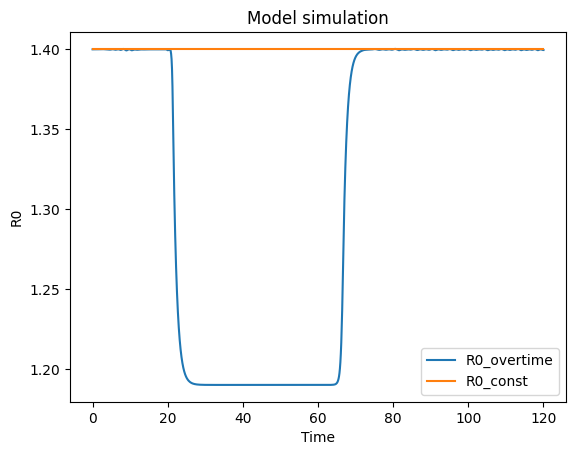

In [214]:
R0_vec = compute_R0(x_vec, q, beta, gamma)

R0_const = beta/gamma

plt.title('R0 constant vs R0 with change of behavior')
plt.plot(t, R0_vec, label = "R0_overtime")
plt.plot(t, np.ones(len(t))*R0_const, label = "R0_const")
plt.legend()
plt.xlabel('Time')
plt.ylabel('R0')
plt.title('Model simulation')

# Variation of parameters

Let's define the variables for the baseline model

In [215]:
#baseline model= 
t_span = (0, 120)
t_eval = np.linspace(*t_span, 1000)

initial_cond = [1-10**(-3), 10**(-3), 0, 0, 1-(10**(-6))]

beta = 0.5
q = 0.85
gamma = 1/2.8
v = gamma
rho = 10
m = 100


### Variation of the m parameter

We consider 1 over m because it is easier to interpret. 
e.g. 1/m = 0.06 is the same of "6% of the total population"

In [216]:
m_variation = [1/0.06, 1/0.024, 1/0.016, 1/0.012, 1/0.008, 1/0.004]

I_m_variation = []
global_t = None
for i in range(len(m_variation)):
    t, _, tmp_i, _, _, _ = compute_model(initial_cond, beta, gamma, q, v, rho, m_variation[i], t_span, t_eval)
    global_t = t

    I_m_variation.append( tmp_i )


Text(0.5, 1.0, 'Model simulation changing m')

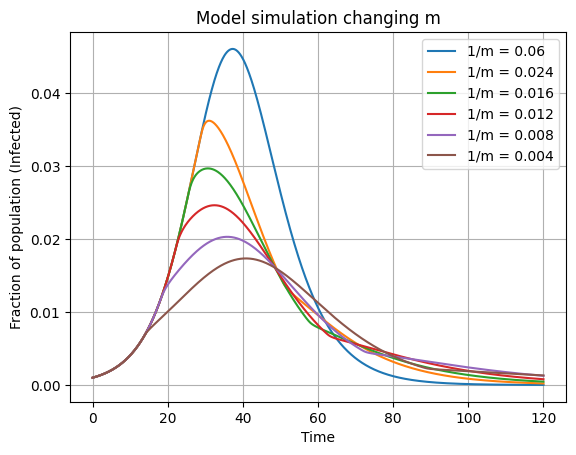

In [217]:
for i in range(len(m_variation)):
    plt.plot(global_t, I_m_variation[i], label = f"1/m = {round(1/m_variation[i], 3)}")

plt.legend()
plt.grid("True")
plt.xlabel('Time')
plt.ylabel('Fraction of population (Infected)')
plt.title('Model simulation changing m')

Let's see how the peak of epidemic changes based on m

In [218]:
m_samples = np.linspace(0.0001, 0.2, 50)
points = []

for samp in m_samples:
    _, _, I_samp, _, _, _ = compute_model(initial_cond, beta, gamma, q, v, rho, 1/samp, t_span, t_eval)
    points.append(max(I_samp))

An unreachable prevalence threshold represents the situation in which the epidemic
is not perceived sufficiently severe to trigger a behavioral response of the population.

This happens when 1/m > 1 - 1/R0n +1/R0n*log(1/R0n)

In [219]:
R0n = beta/gamma
critical_m = 1 - 1/R0n + 1/R0n * math.log(1/R0n)

Text(0.5, 1.0, 'How m influences the spread of the pandemic')

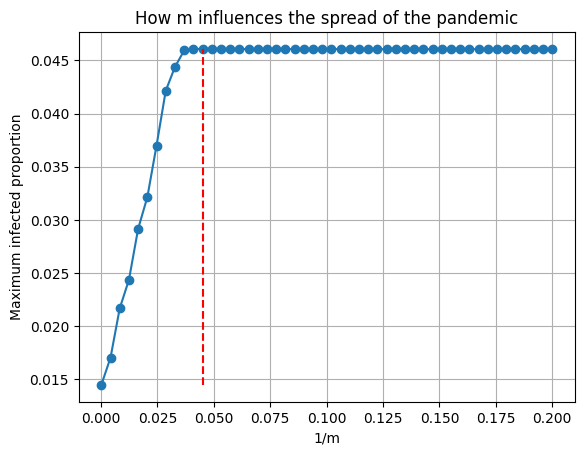

In [220]:
plt.plot(m_samples, points, marker = "o")
plt.vlines(critical_m, ymin = min(points), ymax=max(points), colors = "red", linestyles="--")
plt.grid("True")
plt.xlabel('1/m')
plt.ylabel('Maximum infected proportion')
plt.title('How m influences the spread of the pandemic')

### Variation of the rho parameter

In [221]:
rho_variation = [0.017, 0.56, 1, 3.15, 10, 1000]

I_rho_variation = []
global_t = None
for i in range(len(rho_variation)):
    t, _, tmp_i, _, _, _ = compute_model(initial_cond, beta, gamma, q, v, rho_variation[i], m, t_span, t_eval)
    global_t = t

    I_rho_variation.append( tmp_i )


Text(0.5, 1.0, 'Model simulation')

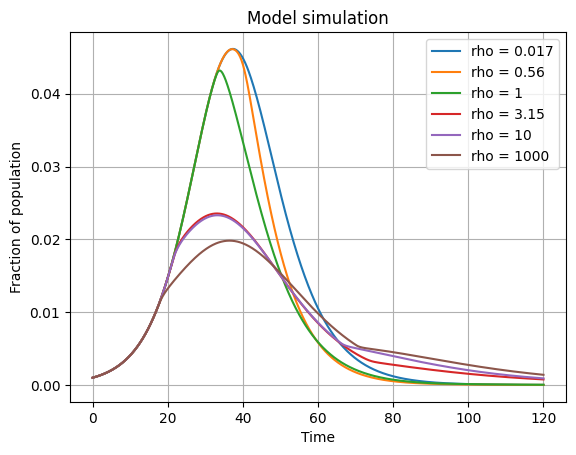

In [222]:
for i in range(len(rho_variation)):
    plt.plot(global_t, I_rho_variation[i], label = f"rho = {round(rho_variation[i], 3)}")

plt.legend()
plt.grid("True")
plt.xlabel('Time')
plt.ylabel('Fraction of population')
plt.title('Model simulation')

In [223]:
rho_samples = np.logspace(np.log10(0.01), np.log10(1000), 50)

points = []

for samp in rho_samples:
    _, _, I_samp, _, _, _ = compute_model(initial_cond, beta, gamma, q, v, samp, m, t_span, t_eval)
    points.append(max(I_samp))


Text(0.5, 1.0, 'Model simulation')

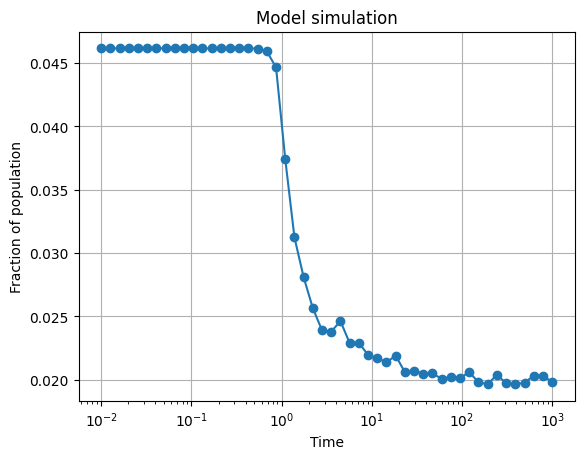

In [224]:
plt.plot(rho_samples, points, marker = "o")
plt.xscale('log')
plt.grid("True")
plt.xlabel('Time')
plt.ylabel('Fraction of population')
plt.title('Model simulation')

### Variation of the q parameter

Text(0.5, 1.0, 'Model simulation')

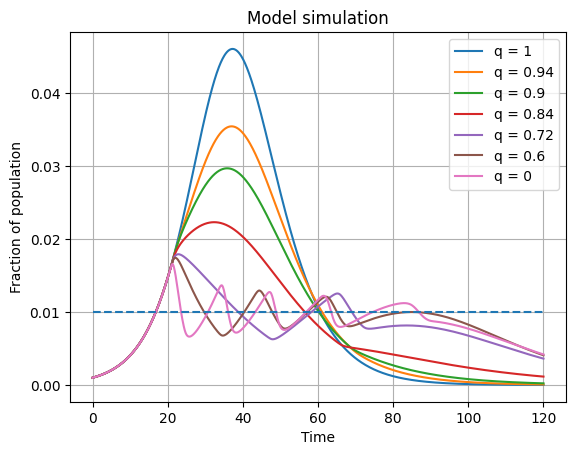

In [ ]:
q_variation = [1, 0.94, 0.9, 0.84, 0.72, 0.6, 0]

I_q_variation = []
global_t = None
for i in range(len(q_variation)):
    t, _, tmp_i, _, _, _ = compute_model(initial_cond, beta, gamma, q_variation[i], v, rho, m, t_span, t_eval)
    global_t = t

    I_q_variation.append( tmp_i )

for i in range(len(q_variation)):
    plt.plot(global_t, I_q_variation[i], label = f"q = {round(q_variation[i], 3)}")

plt.hlines(1/m, xmax=120, xmin=0, linestyles="--")
plt.legend()
plt.grid("True")
plt.xlabel('Time')
plt.ylabel('Fraction of population')
plt.title('Model simulation')


Text(0.5, 1.0, 'Model simulation')

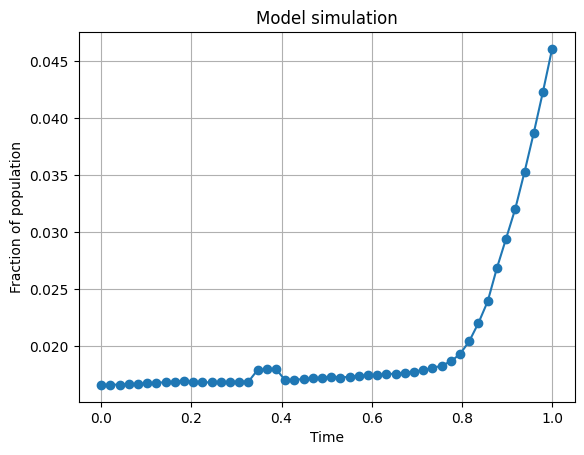

In [226]:
q_samples = np.linspace(0.0001, 1, 50)
points = []

for samp in q_samples:
    _, _, I_samp, _, _, _ = compute_model(initial_cond, beta, gamma, samp, v, rho, m, t_span, t_eval)
    points.append(max(I_samp))


plt.plot(q_samples, points, marker = "o")
plt.grid("True")
plt.xlabel('Time')
plt.ylabel('Fraction of population')
plt.title('Model simulation')

## Variation of v

Text(0.5, 1.0, 'Model simulation changing v')

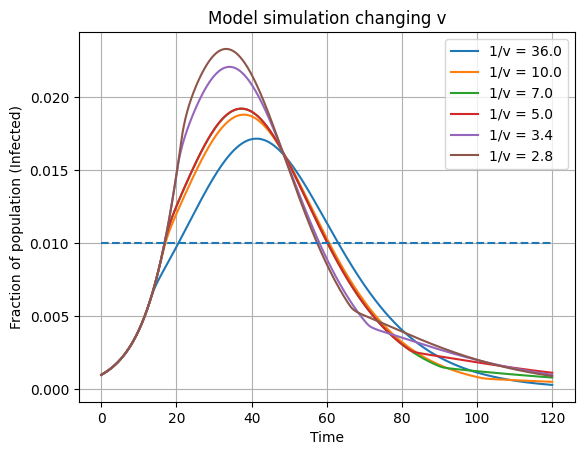

In [249]:
v_variation = [1/36, 1/10, 1/7, 1/5, 1/3.4, 1/2.8]

I_v_variation = []
global_t = None
for i in range(len(v_variation)):
    t, _, tmp_i, _, _, _ = compute_model(initial_cond, beta, gamma, q, v_variation[i], rho, m, t_span, t_eval)
    global_t = t

    I_v_variation.append( tmp_i )

for i in range(len(v_variation)):
    plt.plot(global_t, I_v_variation[i], label = f"1/v = {round(1/v_variation[i], 3)}")

plt.hlines(1/m, xmax=120, xmin=0, linestyles="--")
plt.legend()
plt.grid("True")
plt.xlabel('Time')
plt.ylabel('Fraction of population (Infected)')
plt.title('Model simulation changing v')

Text(0.5, 1.0, 'Model simulation')

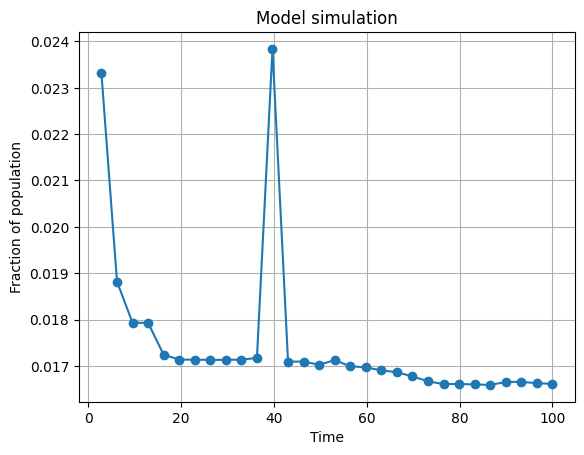

In [239]:
v_samples = np.linspace(2.8, 100, 30)
points = []

for samp in v_samples:
    _, _, I_samp, _, _, _ = compute_model(initial_cond, beta, gamma, q, 1/samp, rho, m, t_span, t_eval)
    points.append(max(I_samp))


plt.plot(v_samples, points, marker = "o")
plt.grid("True")
plt.xlabel('Time')
plt.ylabel('Fraction of population')
plt.title('Model simulation')

In [240]:
v_samples

array([  2.8       ,   6.15172414,   9.50344828,  12.85517241,
        16.20689655,  19.55862069,  22.91034483,  26.26206897,
        29.6137931 ,  32.96551724,  36.31724138,  39.66896552,
        43.02068966,  46.37241379,  49.72413793,  53.07586207,
        56.42758621,  59.77931034,  63.13103448,  66.48275862,
        69.83448276,  73.1862069 ,  76.53793103,  79.88965517,
        83.24137931,  86.59310345,  89.94482759,  93.29655172,
        96.64827586, 100.        ])